### Task 1: Import Libraries and Modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings("ignore")

2026-05-04 06:00:05.142110: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-04 06:00:06.684902: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-04 06:00:06.694310: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-04 06:00:09.965740: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


### Task 2: Load the Dataset

In [2]:
try:
    # Load the CSV file into a DataFrame, using ISO-8859-1 encoding
	df = pd.read_csv('/usercode/car_purchasing.csv', encoding='ISO-8859-1')
	
	# Display summary statistics for all columns, including categorical ones
	print(df.describe(include='all'))
	
	# Show the first five rows to get a sense of the data
	print("_First five rows of the dataset_")
	print(df.head())
	
	# Check for missing values in each column
	print("_Null Values_")
	print(df.isnull().sum())
except:
    # Inform the user if the file path is incorrect or file is missing
	print("File Not found")

       customer name                                    customer e-mail  \
count            500                                                500   
unique           498                                                500   
top             Seth  cubilia.Curae.Phasellus@quisaccumsanconvallis.edu   
freq               2                                                  1   
mean             NaN                                                NaN   
std              NaN                                                NaN   
min              NaN                                                NaN   
25%              NaN                                                NaN   
50%              NaN                                                NaN   
75%              NaN                                                NaN   
max              NaN                                                NaN   

       country      gender         age  annual Salary  credit card debt  \
count      500  500.0000

### Task 3: Create the Pairplots

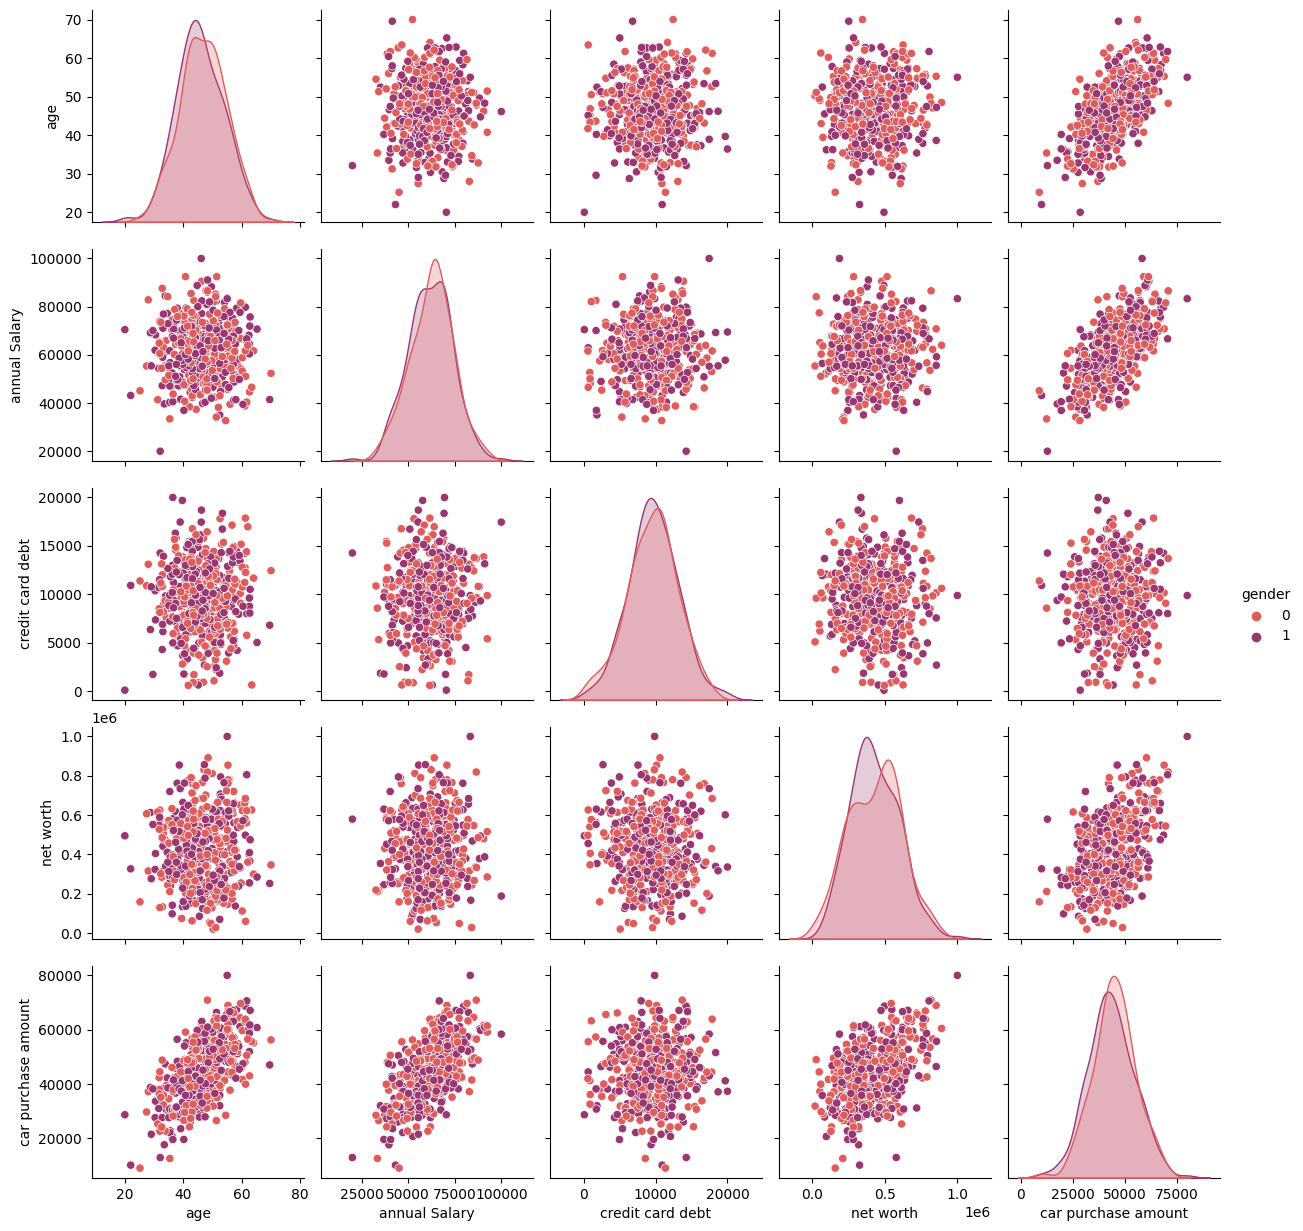

In [3]:
# Create a pairplot to visualize relationships between all numeric columns
# Color points by 'gender' using the 'flare' palette for better distinction
sb.pairplot(df,hue='gender',palette='flare')

### Task 4: Create a Plot to View Purchasing Amount and Net Worth

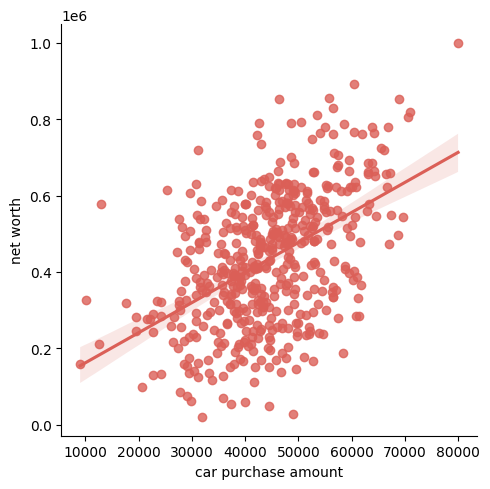

In [4]:
# Set the default color palette for all Seaborn plots to 'hls'
sb.set_palette('hls')

# Create a scatter plot with a linear regression line to visualize the relationship between purchase amount and net worth
sb.lmplot(x='car purchase amount',y='net worth',data=df)

### Task 5: Create a Plot between Purchasing Amount and Age

Text(0.5, 1.0, 'Purchase Amount vs Age hue gender')

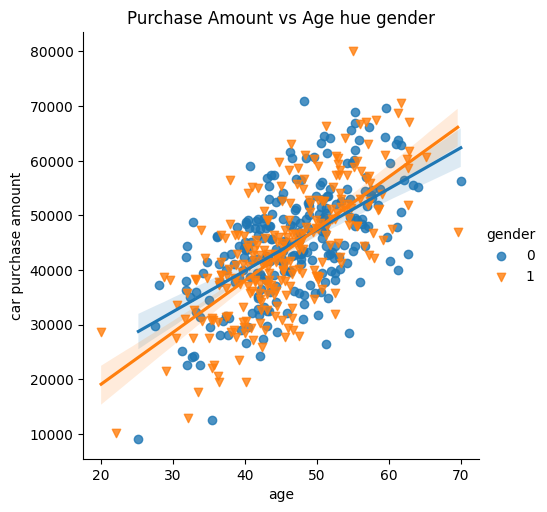

In [5]:
# Different markers for each gender and a specific color palette for clarity
sb.lmplot(x='age',y='car purchase amount',data=df,hue='gender',markers=['o','v'],palette='tab10')

# Title for the plot
plt.title('Purchase Amount vs Age hue gender')

### Task 6: Create Plots for Comparative Analysis

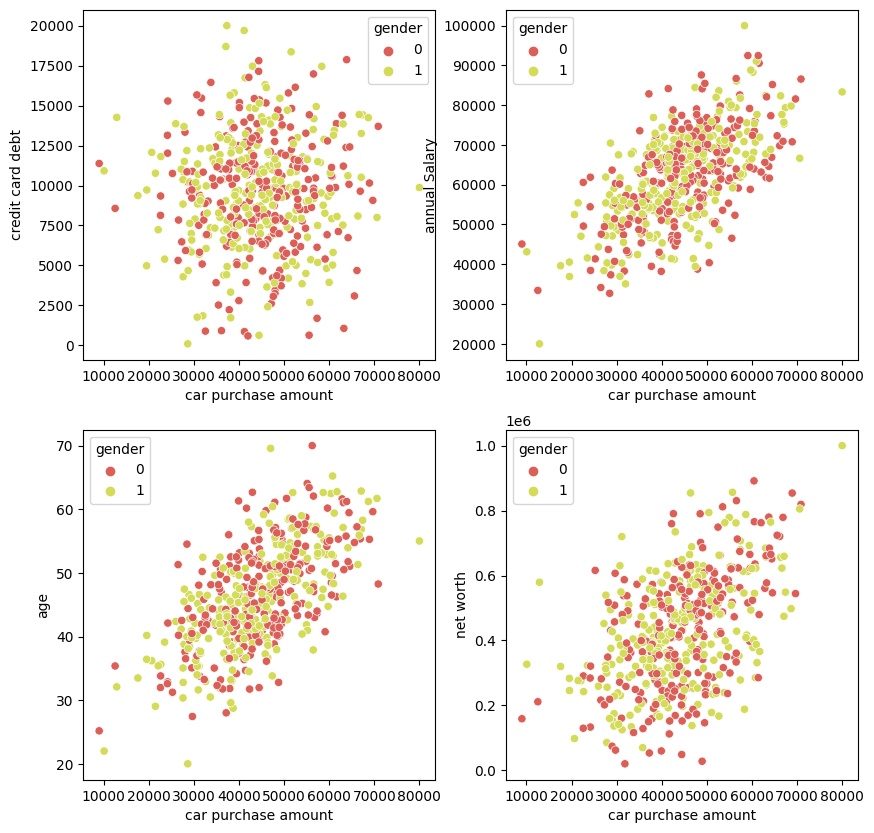

In [6]:
# Create a 2x2 grid of subplots with specified figure size
fig,axes = plt.subplots(2,2,figsize=(10,10))

# List of columns to compare against 'car purchase amount'
cols =[ 'credit card debt','age', 'annual Salary', 'net worth']

# Loop through each column and create a scatter plot on the corresponding subplot
# Color points by 'gender' for differentiation
for i in range(4):
    sb.scatterplot(
        x='car purchase amount', 
        y=cols[i], 
        data=df, 
        ax=axes[i%2,i//2], # Map loop index to 2x2 subplot grid
        hue='gender'
    )

### Task 7: Create Input and Output Parameters

In [7]:
# Remove columns that are not needed for the model
df.drop(columns=['customer name', 'customer e-mail', 'country', 'gender'], inplace=True)

# Define input features by dropping the target column
X = df.drop('car purchase amount', axis=1)

# Define target/output variable
y = df['car purchase amount']

### Task 8: Split the Training and Testing Data

In [8]:
# Initialize MinMaxScaler to scale features between 0 and 1
scaler = MinMaxScaler()

# Scale input features
X = scaler.fit_transform(X)

# Scale target variable and reshape to 2D array
y = scaler.fit_transform(y.values.reshape(-1, 1))

# Split data into training and testing sets (80% train, 20% test)
# random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

### Task 9: Build the Model

In [9]:
# Initialize a sequential neural network model
model = Sequential()

# Add first hidden layer with 10 neurons, ReLU activation, and input dimension matching features
model.add(Dense(10, activation='relu', input_dim=4))

# Add second hidden layer with 10 neurons and ReLU activation
model.add(Dense(10, activation='relu'))

# Add output layer with 1 neuron and linear activation for regression
model.add(Dense(1, activation='linear'))

# Compile the model using Adam optimizer, mean squared error loss, and track mean absolute error
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 10)                50        
                                                                 
 dense_1 (Dense)             (None, 10)                110       
                                                                 
 dense_2 (Dense)             (None, 1)                 11        
                                                                 
Total params: 171
Trainable params: 171
Non-trainable params: 0
_________________________________________________________________


### Task 10: Train the Model

In [10]:
# Train the neural network model on the training data
# epochs=50 means the model will go through the entire dataset 50 times
# validation_split=0.2 reserves 20% of training data for validation
# shuffle=True randomizes the order of samples each epoch for better learning
training = model.fit(X_train, y_train, epochs=50, validation_split=0.2, shuffle=True)

Epoch 1/50
10/10 [==============================] - 1s 31ms/step - loss: 0.6448 - mean_absolute_error: 0.7790 - val_loss: 0.5593 - val_mean_absolute_error: 0.7205
Epoch 2/50
10/10 [==============================] - 0s 7ms/step - loss: 0.4590 - mean_absolute_error: 0.6536 - val_loss: 0.3956 - val_mean_absolute_error: 0.6004
Epoch 3/50
10/10 [==============================] - 0s 7ms/step - loss: 0.3155 - mean_absolute_error: 0.5358 - val_loss: 0.2688 - val_mean_absolute_error: 0.4863
Epoch 4/50
10/10 [==============================] - 0s 7ms/step - loss: 0.2110 - mean_absolute_error: 0.4309 - val_loss: 0.1878 - val_mean_absolute_error: 0.3972
Epoch 5/50
10/10 [==============================] - 0s 7ms/step - loss: 0.1486 - mean_absolute_error: 0.3520 - val_loss: 0.1291 - val_mean_absolute_error: 0.3175
Epoch 6/50
10/10 [==============================] - 0s 7ms/step - loss: 0.0989 - mean_absolute_error: 0.2757 - val_loss: 0.0847 - val_mean_absolute_error: 0.2443
Epoch 7/50
10/10 [=========

### Task 11: Validate The Model

In [11]:
# Use the trained model to make predictions on the test dataset
y_pred = model.predict(X_test)

# Calculate R-squared score to evaluate how well predictions match actual values
accuracy = r2_score(y_test, y_pred)

# Print the model accuracy as a percentage
print("Accuracy : ", accuracy * 100, "%" )

4/4 [==============================] - 0s 2ms/step
Accuracy :  92.70112048018036 %
